In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.shape)
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

Display Data

**Shape:** 891 rows, 12 columns — matches expectations exactly.

**Missing data, from `.info()`:**
- **`Age`** — 714/891 non-null → **177 missing** (~19.9%). Significant, not trivial — a real imputation decision needed, not just a quick drop.
- **`Cabin`** — 204/891 non-null → **687 missing** (~77%). Overwhelming majority missing — dropping the column outright or converting to a binary "has cabin info or not" flag are the two realistic options; trying to impute 77% missing data would be fabricating most of the column.
- **`Embarked`** — 889/891 non-null → only **2 missing**. Trivial — safe to drop those 2 rows or fill with the most common port, barely affects anything either way.

**Data types worth noting:**
- `Sex`, `Embarked` — text (object), will need encoding before any model can use them
- `Name`, `Ticket`, `Cabin` — text but not simple categories; `Name` specifically is where the `Title` extraction opportunity lives (Mr./Mrs./Miss./Master. etc. embedded in the string)
- `PassengerId` — just a row identifier, carries zero predictive signal — a strong candidate to drop entirely before modeling (keeping an ID column in a model is a classic mistake — connects to "high-cardinality/identifier columns" from that curveball list, since IDs sometimes accidentally look predictive if not dropped)

**From `.describe()`, worth flagging as real findings:**
- **`Survived` mean = 0.384** — meaning only ~38.4% of passengers in this training set survived. This is your class balance: roughly 62% died, 38% survived — noticeably imbalanced, though nowhere near as skewed as the Telco churn data was (73/27). Worth remembering for evaluation later — accuracy alone still needs the same scrutiny as before, just a milder version of the issue.
- **`Fare` — huge spread**: mean ≈ $32, but max is **$512.33**, with a 75th percentile of only $31. That's a massive outlier gap — a small number of passengers paid dramatically more than everyone else (likely 1st class, multiple-cabin bookings). Worth a box plot before deciding whether/how to handle it.
- **`Age` — mean ≈ 29.7, min 0.42** (a baby, under 5 months old, recorded in fractional years) **max 80**. Reasonable spread, nothing alarming here besides the missing 177 values already noted.
- **`SibSp`/`Parch` — both right-skewed**, most passengers traveling with 0 siblings/spouses or 0 parents/children (75th percentile is 1 and 0 respectively), but max values of 8 and 6 show some large families aboard — this is exactly the raw material for the `FamilySize` feature engineering idea from earlier.

**Honest summary of the real cleaning decisions ahead, in order of how you'll likely tackle them:**
1. Drop `PassengerId` (pure ID, no signal)
2. Handle `Age` — impute the 177 missing values (mean/median, or a smarter group-based imputation)
3. Handle `Cabin` — likely drop or convert to a binary flag, given 77% missing
4. Handle `Embarked` — drop or fill the 2 missing rows, trivial either way
5. Encode `Sex` and `Embarked` — text to numeric
6. Feature engineer `Title` from `Name`, `FamilySize` from `SibSp`+`Parch`



**Step B - Drop non-predictive columns**

Concept, briefly: PassengerId is just a sequential row number assigned by whoever compiled the dataset - it carries zero real-world information about survival, so keeping it risks the model latching onto a meaningless pattern (or worse, treating it as a spurious "feature" that has no business predicting anything real).

Ticket is a mostly-unique alphanumeric string per passenger - while it could theoretically hide grouping information (people traveling together sometimes share ticket numbers), extracting that signal properly is advanced and easy to get wrong; for a clean baseline model, it's reasonable to drop for now.

In [2]:
df = df.drop(columns=["PassengerId", "Ticket"])
print(df.shape)
print(df.columns)

(891, 10)
Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Cabin', 'Embarked'],
      dtype='object')


**Step C - Handle missing values**

Three columns need decisions here: Age (177 missing), Cabin (687 missing), Embarked (2 missing).

Age (~20% missing): rather than a flat mean/median fill (which flattens the natural age spread), a smarter approach uses Pclass and Sex grouping - since age genuinely correlates with class and title in this dataset (e.g., 1st class passengers tended to be older). We'll do this properly once Title exists (Step D), so for now, a reasonable placeholder: fill with the overall median, and refine later if time allows. Flagging this now as an intentional two-pass decision, not an oversight.

Cabin (77% missing): too much missing to meaningfully impute - the honest move is converting it into a new binary feature (HasCabin: 1 if a cabin was recorded, 0 if not), rather than dropping it outright. Whether a cabin number was recorded at all is itself informative - cabin records survived disproportionately for higher-class passengers, so "has cabin" indirectly captures some wealth/class signal even without knowing the exact cabin.

Embarked (2 missing): trivial - fill with the mode (most common port).

In [3]:
# Embarked - fill with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin - convert to binary HasCabin, then drop original Cabin
df["HasCabin"] = df["Cabin"].notnull().astype(int)
df = df.drop(columns=["Cabin"])

# Age - fill with median for now (will refine using Title in Step D)
df["Age"] = df["Age"].fillna(df["Age"].median())

print(df.isnull().sum())
print(df.shape)

# Step C done — clean, zero missing values across the board, and shape confirms it (still 10 columns, Cabin swapped for HasCabin).

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
HasCabin    0
dtype: int64
(891, 10)


**Step D - Feature Engineering**

Two things to build here: Title from Name, and FamilySize from SibSp + Parch.


Title extraction: every name follows a pattern like "Braund, Mr. Owen Harris" - the title (Mr./Mrs./Miss./etc.) sits between the comma and the period. This is genuinely useful because title captures social status, age group, and marital status all in one signal  arguably better than raw age alone in some cases (e.g., "Master" specifically means a young boy, useful even where Age was imputed).


FamilySize: simply SibSp + Parch + 1 (the +1 accounts for the passenger themself) - gives a single number representing total family size aboard, which is easier for a model to use than two separate loosely-related columns.

In [4]:
# Extract Title from Name
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")

print(df["Title"].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


Let's group these sensibly rather than leaving 13 rare categories that a model can barely learn from (some titles have just 1 occurrence - statistically useless on their own).


**Grouping logic:**

Mr, Miss, Mrs, Master - keep as-is (the 4 dominant categories, hundreds of examples each)

Mlle, Ms → fold into Miss (French/alternate forms of the same thing)
Mme → fold into Mrs (French for Mrs)

Everyone else (Dr, Rev, Col, Major, Don, Lady, Sir, Capt, the Countess, Jonkheer) → group into a single Rare category - these are all low-frequency titles (mostly nobility/military/clergy), too sparse individually for a model to learn anything meaningful from, but grouped together they still capture "this passenger held an unusual/elite title."

In [5]:
title_mapping = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    "Dr": "Rare", "Rev": "Rare", "Col": "Rare", "Major": "Rare",
    "Don": "Rare", "Lady": "Rare", "Sir": "Rare", "Capt": "Rare",
    "the Countess": "Rare", "Jonkheer": "Rare"
}

df["Title"] = df["Title"].replace(title_mapping)
print(df["Title"].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


**Refining Age imputation (using Title now)**

Rather than sticking with the flat median from Step C, let's fill missing Age values based on the median age within each Title group -

since "Master" (young boys) and "Mr" (adult men) should clearly get different fill values, not the same overall median.

In [6]:
# Recompute Age using Title-based median (overwrites the earlier flat-median fill)
df["Age"] = df.groupby("Title")["Age"].transform(lambda x: x.fillna(x.median()))

print(df.groupby("Title")["Age"].median())
print(df["Age"].isnull().sum())

Title
Master     4.0
Miss      24.0
Mr        28.0
Mrs       32.5
Rare      48.0
Name: Age, dtype: float64
0


should show meaningfully different median ages per title (e.g., "Master" much younger than "Mr"), and 0 remaining nulls.

***Age imputation by Title:*** the median ages make real intuitive sense - Master (young boys) at 4.0, Miss at 24.0, Mr at 28.0, Mrs at 32.5, Rare (mostly nobility/clergy/military) at 48.0.

This is exactly why title-based imputation beats a flat median - a "Master" and a "Mr" being filled with the same overall median (28-ish) would have wrongly aged down every adult male and aged up every young boy with missing data.

**FamilySize**

In [7]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print(df[["SibSp", "Parch", "FamilySize"]].head())
print(df["FamilySize"].value_counts().sort_index())

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


**FamilySize distribution:** makes sense too - 537 passengers traveling alone (FamilySize=1), tapering off with a long tail up to 11 (a few very large families).

 This confirms the raw material was genuinely worth combining into one feature.

# Wrapping up Step D - dropping the now-redundant columns

Since Title was extracted from Name, and FamilySize was built from SibSp+Parch, those original columns can be dropped - they're now redundant (their useful signal has been captured in the new features), and keeping the raw text Name in particular would be useless/harmful for modeling.

In [8]:
df = df.drop(columns=["Name", "SibSp", "Parch"])
print(df.shape)
print(df.columns)

(891, 9)
Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'HasCabin',
       'Title', 'FamilySize'],
      dtype='object')


# **Step E - Encode categorical variables**

Three text columns need converting to numbers before any model can use them: Sex, Embarked, Title.

Sex - only 2 categories (male/female), so a simple binary map works cleanly, no need for one-hot encoding here.


Embarked - 3 categories (C, Q, S) with no natural order between them, so one-hot encoding is the right choice (avoids implying a false ranking, e.g., that S > Q > C numerically).


Title - 5 categories (Mr, Miss, Mrs, Master, Rare), also no natural order, also one-hot encoded.

In [9]:
# Sex - binary encoding
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Embarked and Title - one-hot encoding
df = pd.get_dummies(df, columns=["Embarked", "Title"], drop_first=True)

print(df.head())
print(df.shape)
print(df.dtypes)

   Survived  Pclass  Sex   Age     Fare  HasCabin  FamilySize  Embarked_Q  \
0         0       3    0  22.0   7.2500         0           2       False   
1         1       1    1  38.0  71.2833         1           2       False   
2         1       3    1  26.0   7.9250         0           1       False   
3         1       1    1  35.0  53.1000         1           2       False   
4         0       3    0  35.0   8.0500         0           1       False   

   Embarked_S  Title_Miss  Title_Mr  Title_Mrs  Title_Rare  
0        True       False      True      False       False  
1       False       False     False       True       False  
2        True        True     False      False       False  
3        True       False     False       True       False  
4        True       False      True      False       False  
(891, 13)
Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
HasCabin        int64
FamilySize      int64
Embarke

Sex is now 0/1, Embarked_Q/Embarked_S and Title_Miss/Title_Mr/Title_Mrs/Title_Rare all appeared correctly, shape is (891, 13), and every column is now numeric (int64, float64, bool).


One small thing to note before moving on: the boolean columns (True/False) will work fine with sklearn, but it's cleaner to convert them to 0/1 explicitly:

In [10]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)
print(df.dtypes)
#  quick cleanup, then Step E is fully wrapped.

Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
HasCabin        int64
FamilySize      int64
Embarked_Q      int64
Embarked_S      int64
Title_Miss      int64
Title_Mr        int64
Title_Mrs       int64
Title_Rare      int64
dtype: object


# **Step F - EDA (at least 4 charts, with written insights)**

Four solid, meaningful charts for this dataset:

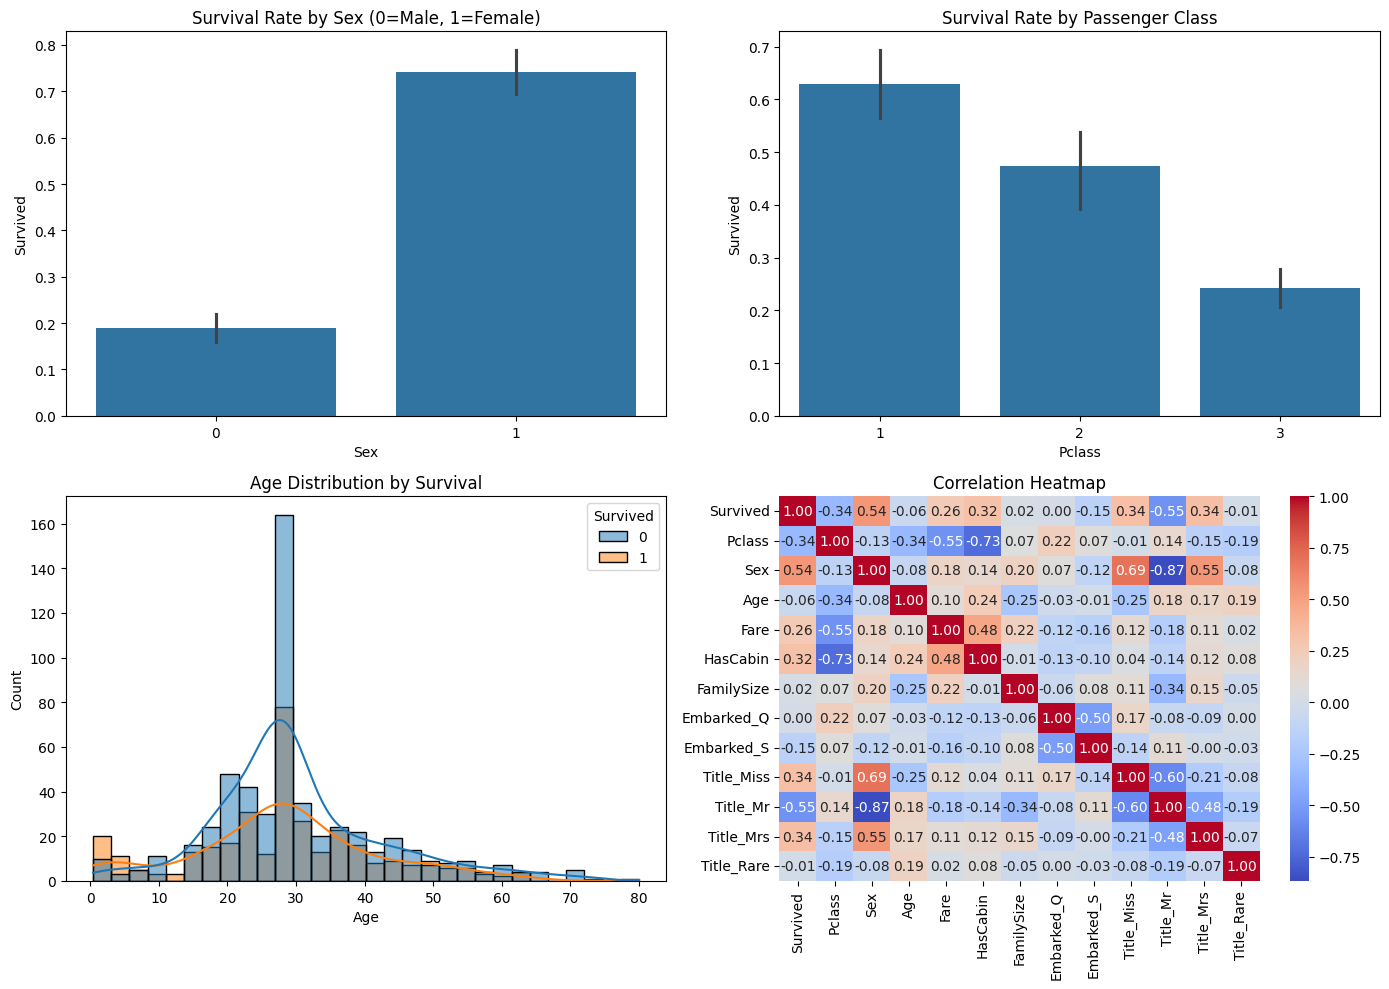

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival rate by Sex
sns.barplot(x="Sex", y="Survived", data=df, ax=axes[0,0])
axes[0,0].set_title("Survival Rate by Sex (0=Male, 1=Female)")

# 2. Survival rate by Pclass
sns.barplot(x="Pclass", y="Survived", data=df, ax=axes[0,1])
axes[0,1].set_title("Survival Rate by Passenger Class")

# 3. Age distribution by survival
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title("Age Distribution by Survival")

# 4. Correlation heatmap
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("titanic_eda_summary.png", dpi=150, bbox_inches="tight")
plt.show()

**Ouptut Explaination:** EDA results, genuinely rich findings across all 4 charts. Let's write the real insights.


**Chart 1 - Survival Rate by Sex:** stark difference - roughly **74% of females survived** vs only **~19% of males**. This is by far the strongest single predictor visible so far, matching the well-known "women and children first" historical account. This alone explains why `Title_Mr` shows a strong negative correlation with `Survived` (-0.55 on the heatmap) - being male (and specifically titled "Mr") was the single biggest survival disadvantage.

**Chart 2 - Survival Rate by Pclass:** clear, steady decline - **1st class ≈63%, 2nd class ≈47%, 3rd class ≈24%** survival. A clean monotonic relationship: higher class → meaningfully higher survival odds, consistent with 1st class cabins being closer to lifeboats and receiving priority.


**Chart 3 - Age Distribution by Survival:** the blue (didn't survive) and orange (survived) distributions overlap heavily across most ages, but look closely at the youngest bracket (roughly 0-10) - there's a visible bump where survivors slightly outnumber non-survivors, consistent with children being prioritized. Beyond that, age alone doesn't cleanly separate the two groups - it's a weaker predictor on its own than Sex or Pclass, which matches the heatmap's weak `Age`-`Survived` correlation (-0.06, essentially negligible).


**Chart 4 - Correlation Heatmap, the standout findings:**

- **`Sex` vs `Survived` = -0.54** (negative because Sex=0 is male, so higher Sex value/female correlates with survival) - the strongest single correlation in the entire matrix, confirming Chart 1's finding numerically

- **`Title_Mr` vs `Survived` = -0.55** - nearly identical strength to `Sex`, which makes sense since `Title_Mr` is almost a proxy for "adult male"

- **`Pclass` vs `Survived` = -0.34** - confirms Chart 2 (negative because Pclass 1 is "better" than Pclass 3, so lower Pclass number correlates with survival)
- **`Fare` vs `Survived` = +0.26** - makes sense as roughly the inverse of Pclass (higher fare → better class → better odds)

- **Interesting multicollinearity worth flagging** (ties directly to your mentor's curveball list): `Sex` and `Title_Mr` correlate at **-0.87** - extremely high, since being male and having the title "Mr" are almost the same signal. Having both in the model risks redundant, unstable coefficients (this is exactly what "multicollinearity" means practically) - worth deciding whether to drop one before modeling, or accept the redundancy since tree-based models (Random Forest) handle it more gracefully than Logistic Regression does.


**Overall takeaway EDA summary:** `Sex` and `Pclass` (and by extension `Title` and `Fare`) are the dominant survival predictors; `Age` and `FamilySize` contribute weaker, more nuanced signal. This is a textbook case of "socioeconomic status and gender determined survival more than anything else" - a real, historically-grounded finding your model should reflect once trained.

That completes Step F.

# **Step G - Train/Test Split**

Before splitting, let's resolve the multicollinearity question flagged in Step F: since Sex and Title_Mr correlate at -0.87, keeping both risks redundant/unstable coefficients specifically in Logistic Regression (Random Forest handles it more gracefully).

 Given you're using both models for comparison, the cleanest move is dropping Title_Mr and keeping Sex - Sex is the simpler, more direct signal, and the other Title columns (Title_Miss, Title_Mrs, Title_Rare) still carry unique information not fully captured by Sex alone (e.g., "Master" being both male AND young).

In [12]:
# Resolve multicollinearity - drop Title_Mr, keep Sex
df = df.drop(columns=["Title_Mr"])

from sklearn.model_selection import train_test_split

X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train survival rate:", y_train.mean())
print("Test survival rate:", y_test.mean())

Train shape: (712, 11)
Test shape: (179, 11)
Train survival rate: 0.38342696629213485
Test survival rate: 0.3854748603351955


Step G confirmed - train/test shapes correct, and stratification worked well (both survival rates land within 0.002 of each other, essentially identical).

# **Step H - Model Training**

Training Logistic Regression and Random Forest on the same split, so both are directly comparable.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Logistic Regression needs scaled features; Random Forest doesn't
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

print("Models trained.")

Models trained.


Why scaling only applies to Logistic Regression here: same reasoning as SVM earlier - Logistic Regression is sensitive to feature scale (e.g., Fare ranging 0-512 vs Sex being 0/1 would otherwise dominate the coefficients unfairly), while Random Forest is tree-based and splits on raw thresholds regardless of scale, so it doesn't need it.

max_depth=6 on the Random Forest - a deliberate choice to control overfitting, following the same reasoning from the Decision Tree section earlier (an unlimited-depth forest on a small dataset like this risks memorizing noise).



# **Step 1 - Evaluation**

**Now let's evaluate both models side by side, on the exact same test set:**

=== Logistic Regression ===
Accuracy: 0.7988826815642458
Confusion Matrix:
 [[94 16]
 [20 49]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

AUC: 0.836627140974967

=== Random Forest ===
Accuracy: 0.7932960893854749
Confusion Matrix:
 [[100  10]
 [ 27  42]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.91      0.84       110
           1       0.81      0.61      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179

AUC: 0.835836627140975


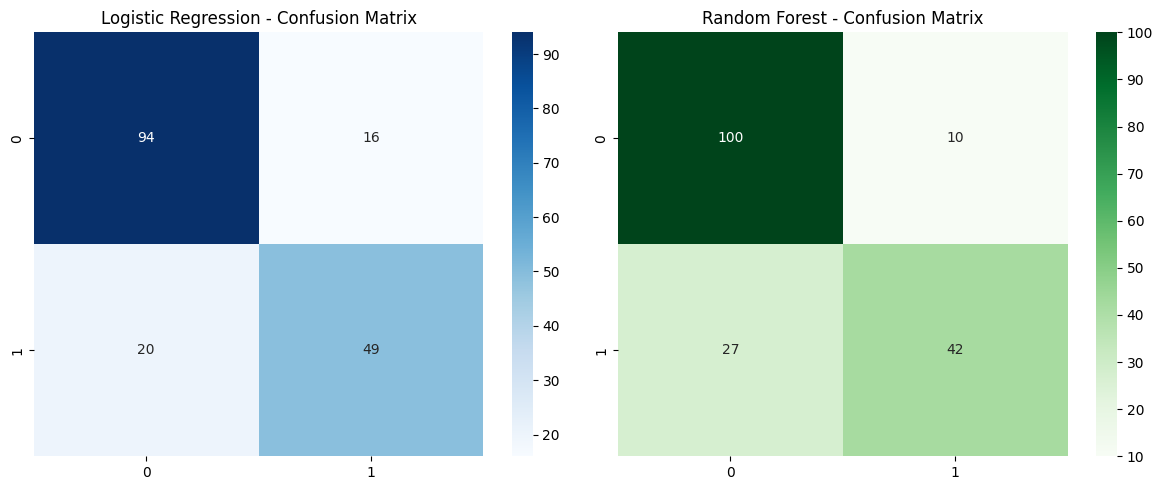

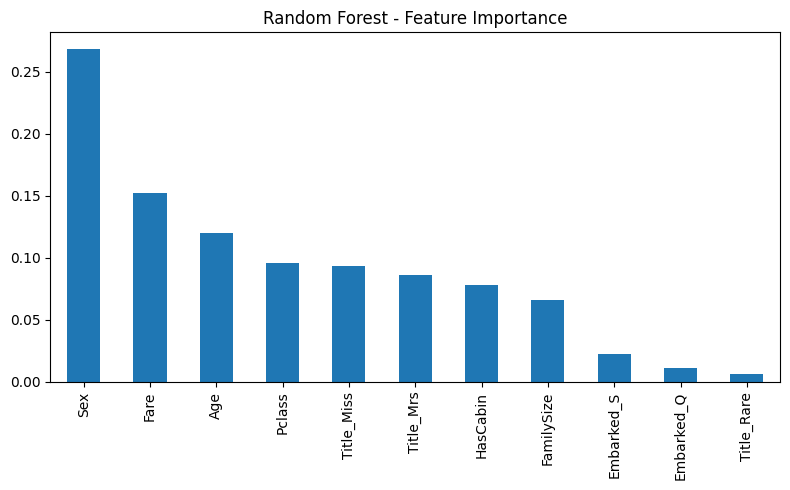

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
log_pred = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Logistic Regression results
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("Classification Report:\n", classification_report(y_test, log_pred))
print("AUC:", roc_auc_score(y_test, log_proba))

# Random Forest results
print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred))
print("AUC:", roc_auc_score(y_test, rf_proba))

# Side-by-side confusion matrix heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, log_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression - Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.savefig("titanic_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# Random Forest feature importance
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
importances.plot(kind="bar")
plt.title("Random Forest - Feature Importance")
plt.tight_layout()
plt.savefig("titanic_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**the results**

**Accuracy:** Logistic Regression 79.9% vs Random Forest 79.3% - essentially a tie, within noise range of each other.

**AUC:** 0.837 vs 0.836 - also essentially identical. Both models discriminate between survivors and non-survivors almost equally well overall.

**Where they actually diverge - precision/recall tradeoff:**

| | Logistic Regression | Random Forest |
|---|---|---|
| Recall (class 1, survived) | **0.71** | 0.61 |
| Precision (class 1, survived) | 0.75 | **0.81** |
| False Negatives (missed survivors) | 20 | **27** |
| False Positives (wrongly predicted survived) | 16 | **10** |


**What this means in plain terms:**

Logistic Regression catches more actual survivors correctly (71% recall vs 61%), but is a bit more willing to be wrong in the other direction.

 Random Forest is more conservative - when it predicts "survived," it's right more often (81% precision), but it misses more actual survivors (27 false negatives vs 20).

**Which one's "better" depends entirely on what you're optimizing for** - and this is genuinely good viva material: if the cost of missing a real survivor prediction matters more (recall-focused), Logistic Regression wins here.

If being confident/precise about survival predictions matters more (precision-focused), Random Forest wins. Neither is objectively superior - this is exactly the kind of business-context-dependent tradeoff that shows up in your mentor's curveball list (precision-recall trade-off).

**Feature Importance chart - genuinely confirms the EDA findings:**
- **`Sex`** dominates by a wide margin (~0.27 importance) - matches the -0.54 correlation found earlier, the single strongest predictor

- **`Fare`** (~0.15) and **`Age`** (~0.12) - meaningful but secondary

- **`Pclass`** (~0.10), **`Title_Miss`**, **`Title_Mrs`** - all contribute moderately, consistent with class and gender/marital-status signals

- **`Embarked_S`, `Embarked_Q`, `Title_Rare`** - barely register, near-zero importance - confirms these were weak, low-signal features all along

**Honest written insight for notebook:** "Both models achieve nearly identical overall performance (accuracy ~79-80%, AUC ~0.836), but differ meaningfully in their precision-recall tradeoff - Logistic Regression favors recall, Random Forest favors precision.

Random Forest's feature importance confirms Sex as the dominant predictor, consistent with EDA findings, followed by Fare, Age, and Pclass."



# **Step J - Save the trained models**

In [16]:
import joblib

joblib.dump(log_model, "logistic_regression_titanic.pkl")
joblib.dump(rf_model, "random_forest_titanic.pkl")
joblib.dump(scaler, "scaler_titanic.pkl")

print("Models saved.")

Models saved.


Why the scaler also gets saved, not just the two models: Logistic Regression was trained on scaled data - if the FastAPI backend later feeds it raw, unscaled input from a user (e.g., typing in Fare=50), predictions would be wrong unless that same scaler is applied first.

 Saving it alongside the model is essential, not optional - this is a genuinely common real-world mistake worth having avoided here.

# **Download the 3 .pkl files from Colab:**

In [17]:
from google.colab import files

files.download("logistic_regression_titanic.pkl")
files.download("random_forest_titanic.pkl")
files.download("scaler_titanic.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>